Testing the Sensors ability to correctly diagnose component states

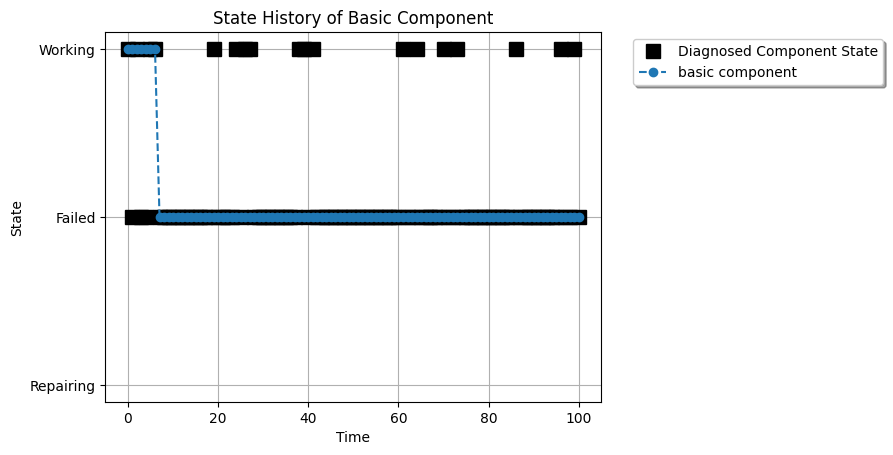

Diagnosis Sensor Accuracy: 83.17%


In [27]:
from sensor_objects.DiagnosisSensor import DiagnosisSensor
from component_objects.component_exponential import ExponentialComponent

import numpy as np
import matplotlib.pyplot as plt

num_time_steps = 100

comp = ExponentialComponent("basic component", MTTF=5, MTTR=2)
comp.simulate(num_time_steps)

# print(type(comp.history[5,1]))

sensor = DiagnosisSensor("basic diagnosis sensor", comp)
sensed_states = np.zeros(num_time_steps+1, dtype=int)
for i in range(num_time_steps+1):
    sensor.observation_matrix(i)
    sensed_states[i] = sensor.sensorLogic(int(comp.history[i,1]), i)

plt.plot(comp.history[:,0], sensed_states, 'ks', markersize= 10,  label="Diagnosed Component State")
comp.plot_history()

# calculate the accuracy
correct_diagnoses = np.sum(sensed_states == comp.history[:,1])
accuracy = correct_diagnoses / (num_time_steps + 1) * 100
print(f"Diagnosis Sensor Accuracy: {accuracy:.2f}%")

